# Modelado con la variable Approved_Flag

In [1]:
# Librerías básicas
import numpy as np
import pandas as pd
import os
import joblib

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Métodos de validación y ajuste de modelos
from sklearn.model_selection import GridSearchCV, train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from scipy.stats import randint, uniform
from sklearn.preprocessing import MinMaxScaler

# Modelos de regresión
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.svm import LinearSVR
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

# SHAP para explicación de modelos
import shap
shap.initjs()

# Importación de módulos personalizados
from modulos.data_description import *
from modulos.data_model import *
from modulos.data_visualization import *

## 1. Carga del Dataset

In [2]:
# Cargamos el dataset internal_transformed
ruta_binario = os.path.join('data', 'internal_transformed.pkl')
internal_transformed = joblib.load(ruta_binario)

# Eliminamos la variable 'Credit_Score' para que no esté duplicada
internal_transformed.drop(columns='Credit_Score', inplace=True)

In [3]:
# Cargamos el dataset external_transformed
ruta_binario = os.path.join('data', 'external_transformed.pkl')
external_transformed = joblib.load(ruta_binario)

### Unión ambos Dataset

In [4]:
# Fusión de DataFrames por PROSPECTID  
df = pd.merge(internal_transformed, external_transformed, on=['PROSPECTID'], how='inner')

### División del Dataset

In [5]:
# Separamos variable dependiente de las independientes
X = df.drop(columns=['Credit_Score', 'PROSPECTID'], inplace=False)
Y = df['Credit_Score']

# Generamos el dataset de entrenamiento y el de test
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=29, shuffle=True)

## 2. Regularización (Ridge, Lasso, ElasticNet)

### 2.1. Linear Regression

In [6]:
# Entrenamiento del modelo de regresión lineal  
linear = LinearRegression(fit_intercept=True)
linear.fit(X_train, y_train)

LinearRegression()

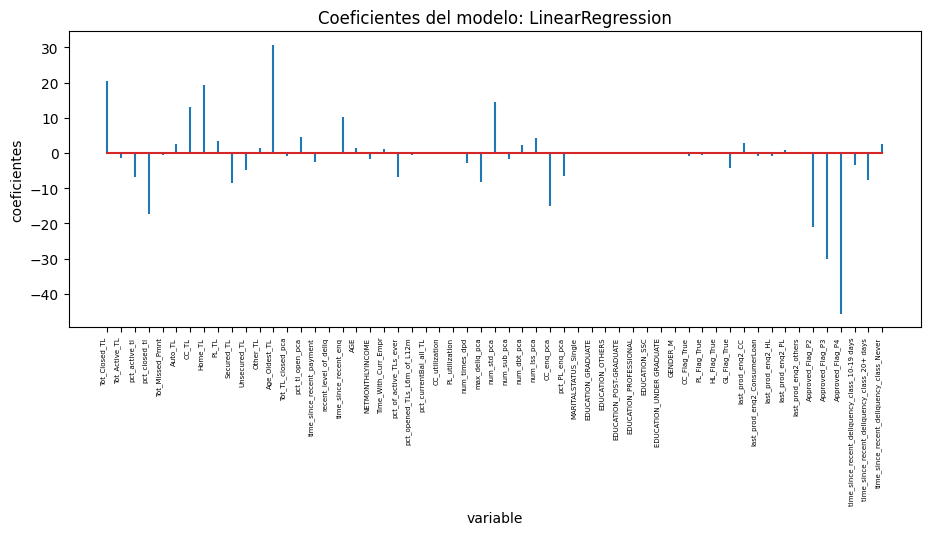

In [7]:
# Gráfico de los coeficientes del modelo  
graficar_coeficientes(linear, X_train)


In [8]:
# Evalúa el modelo entrenado con los datos de prueba
evaluar_modelos(linear, X_test, y_test)

,R^2,RMSE
LinearRegression,0.806172,9.228732


### 2.2. Ridge

In [9]:
# Entrenamiento del modelo Ridge con validación cruzada
modelo_ridge = RidgeCV(
    alphas=np.logspace(-3, 10, 200),
    store_cv_values=True,
    fit_intercept=False
).fit(X_train, y_train)

C:\Users\Ismael Laso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


In [10]:
# # OJO: Tiempo de computo elevado
# # Cálculo y grafico de la evolución de los coeficientes
# evaluacion_coeficientes(modelo_ridge, Ridge, X_train, y_train)

C:\Users\Ismael Laso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:110: FutureWarning: Attribute `cv_values_` is deprecated in version 1.5 and will be removed in 1.7. Use `cv_results_` instead.
  warnings.warn(msg, category=FutureWarning)


Mejor valor de alpha encontrado: 0.001
Mejor valor de alpha encontrado + 1 desviación estándar: 17.62914118095948


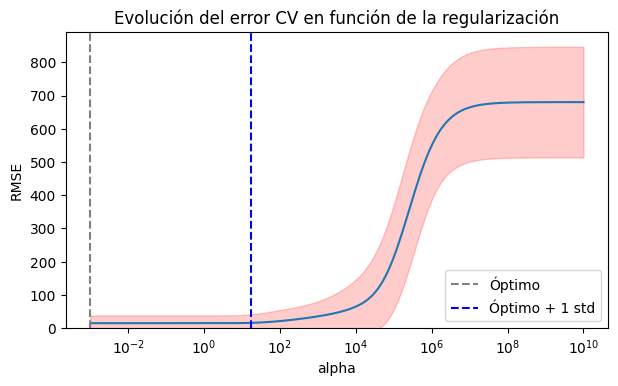

In [11]:
# Calculo y grafico mejor RMSE y su desviación estándar
optimo_ridge, optimo_ridge_1sd = graficar_error_cv(modelo_ridge)

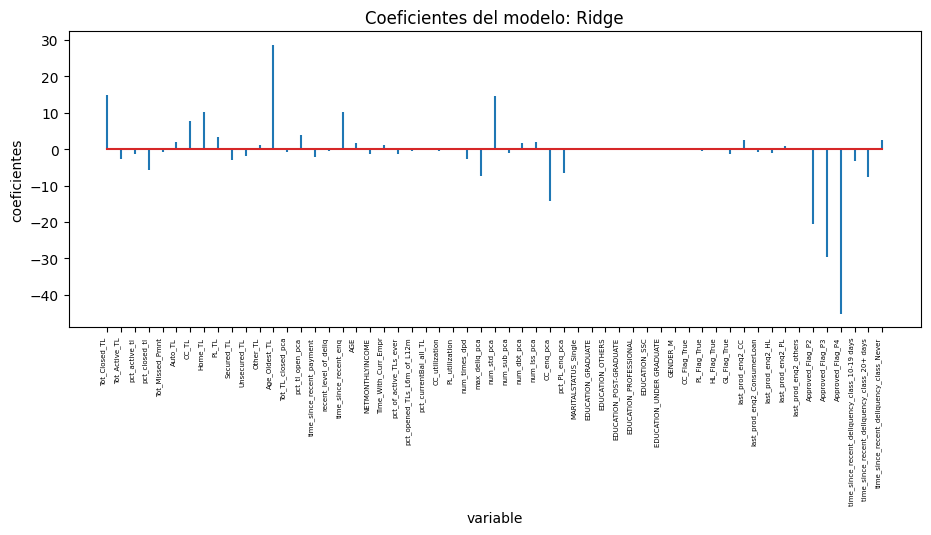

In [12]:
# Entrenamiento del modelo Ridge final con el alpha seleccionado
modelo_ridge_final = Ridge(alpha=optimo_ridge_1sd, fit_intercept=True).fit(X_train, y_train)

# Gráfico de los coeficientes del modelo  
graficar_coeficientes(modelo_ridge_final, X_train)

In [13]:
# Evalúa el modelo entrenado con los datos de prueba
evaluar_modelos(modelo_ridge_final, X_test, y_test)

,R^2,RMSE
LinearRegression,0.806172,9.228732
Ridge,0.804631,9.265352


### 2.3. Lasso

In [14]:
# Entrenamiento del modelo Lasso con validación cruzada
modelo_lasso = LassoCV(
    alphas=np.logspace(-8, 1, 200), 
    cv=3, 
    fit_intercept=True,
).fit(X_train, y_train)

C:\Users\Ismael Laso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.880e+05, tolerance: 1.707e+03
  model = cd_fast.enet_coordinate_descent(


In [15]:
# # OJO: Tiempo de computo elevado
# # Cálculo y grafico de la evolución de los coeficientes
# evaluacion_coeficientes(modelo_lasso, Lasso, X_train, y_train)

Mejor valor de alpha encontrado: 0.0002196385372416547
Mejor valor de alpha encontrado + 1 desviación estándar: 0.04008806328898465


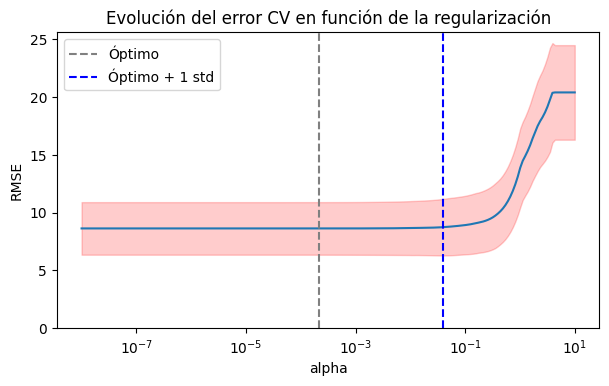

In [16]:
# Calculo y grafico mejor RMSE y su desviación estándar
optimo_lasso, optimo_lasso_1sd = graficar_error_cv(modelo_lasso)

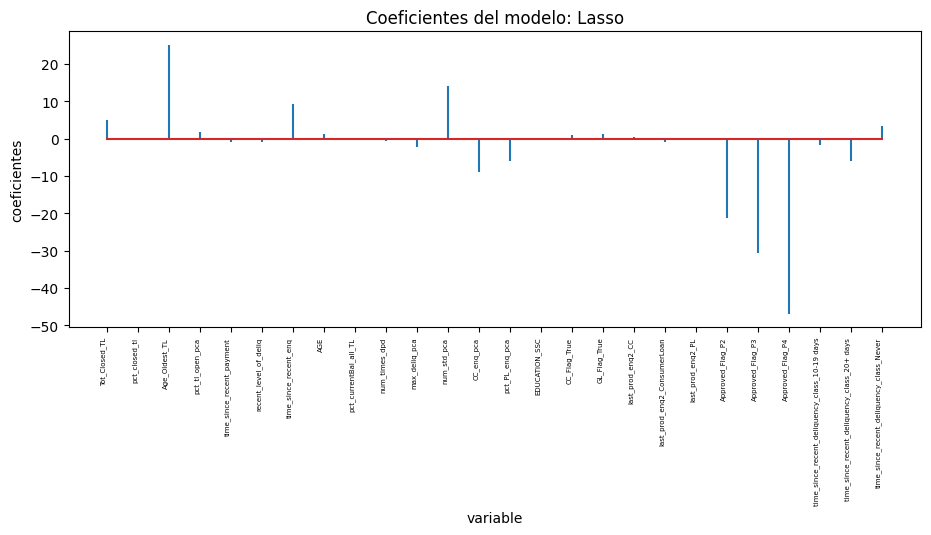

In [17]:
# Entrenamiento del modelo Lasso final con el alpha seleccionado
modelo_lasso_final = Lasso(alpha=optimo_lasso_1sd, fit_intercept=True).fit(X_train, y_train)

# Gráfico de los coeficientes del modelo  
graficar_coeficientes(modelo_lasso_final, X_train)

In [18]:
# Evalúa el modelo entrenado con los datos de prueba
evaluar_modelos(modelo_lasso_final, X_test, y_test)

,R^2,RMSE
LinearRegression,0.806172,9.228732
Ridge,0.804631,9.265352
Lasso,0.798215,9.416252


### 2.4. Elastic Net

In [19]:
# ElasticNetCV - Ajuste y selección de alpha óptimo
modelo_elastic = ElasticNetCV(
    l1_ratio=[0, 0.1, 0.4, 0.7, 0.9, 0.95, 1],
    alphas=np.logspace(-5, 3, 100),
    cv=3,
    tol=0.0001,
    fit_intercept=True, 
).fit(X_train, y_train)

C:\Users\Ismael Laso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Ismael Laso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5679567.45560017, tolerance: 1136.1206500000003
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Ismael Laso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarn

In [20]:
# # OJO: Tiempo de computo elevado
# # Cálculo y grafico de la evolución de los coeficientes
# evaluacion_coeficientes(modelo_elastic, ElasticNet, X_train, y_train)

In [21]:
# Error medio de las 10 particiones por cada valor de alpha y l1_ratio 
mean_error_cv = modelo_elastic.mse_path_.mean(axis =2)

# El resultado es un array de dimensiones (n_l1_ratio, n_alpha)
# Se convierte en un dataframe
df_resultados_cv = pd.DataFrame(
                        data   = mean_error_cv.flatten(),
                        index  = pd.MultiIndex.from_product(
                                    iterables = [modelo_elastic.l1_ratio, modelo_elastic.alphas_],
                                    names     = ['l1_ratio', 'modelo_elastic.alphas_']
                                 ),
                        columns = ["mse_cv"]
                    )

df_resultados_cv['rmse_cv'] = np.sqrt(df_resultados_cv['mse_cv'])
df_resultados_cv = df_resultados_cv.reset_index().sort_values('mse_cv', ascending = True)
df_resultados_cv

,l1_ratio,modelo_elastic.alphas_,mse_cv,rmse_cv
683,1.0,0.000196,74.360738,8.623267
682,1.0,0.000236,74.360761,8.623269
684,1.0,0.000163,74.360799,8.623271
685,1.0,0.000135,74.360906,8.623277
681,1.0,0.000285,74.360929,8.623278
...,...,...,...,...
403,0.9,572.236766,415.598360,20.386230
404,0.9,475.081016,415.598360,20.386230
405,0.9,394.420606,415.598360,20.386230
326,0.7,7.924829,415.598360,20.386230


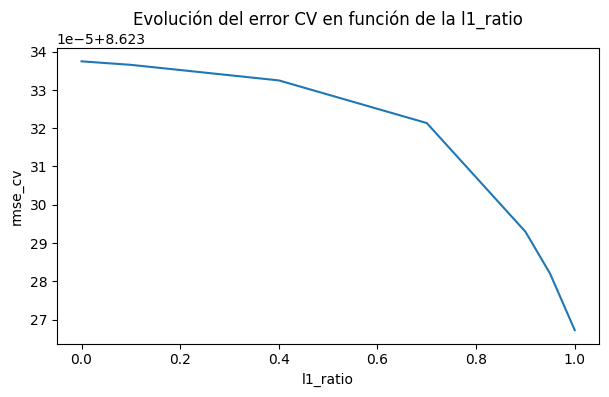

In [22]:
# Mejor valor encontrado para cada l1_ratio
fig, ax = plt.subplots(figsize=(7, 3.84))
df_resultados_cv.groupby('l1_ratio')['rmse_cv'].min().plot(ax = ax)
ax.set_title('Evolución del error CV en función de la l1_ratio')
ax.set_xlabel('l1_ratio')
ax.set_ylabel('rmse_cv');

In [23]:
# Mejor valor alpha y l1_ratio_ encontrado
print(f"Mejor valor de alpha encontrado: {modelo_elastic.alpha_}")
print(f"Mejor valor de l1_ratio encontrado: {modelo_elastic.l1_ratio_}")

Mejor valor de alpha encontrado: 0.00019630406500402724
Mejor valor de l1_ratio encontrado: 1.0


In [24]:
# Ajuste del modelo ElasticNet final con el valor óptimo de alpha y l1_ratio
modelo_elastic_final = ElasticNet(alpha=modelo_elastic.alpha_, l1_ratio=modelo_elastic.l1_ratio_, fit_intercept=True).fit(X_train, y_train)

C:\Users\Ismael Laso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.421e+05, tolerance: 1.707e+03
  model = cd_fast.enet_coordinate_descent(


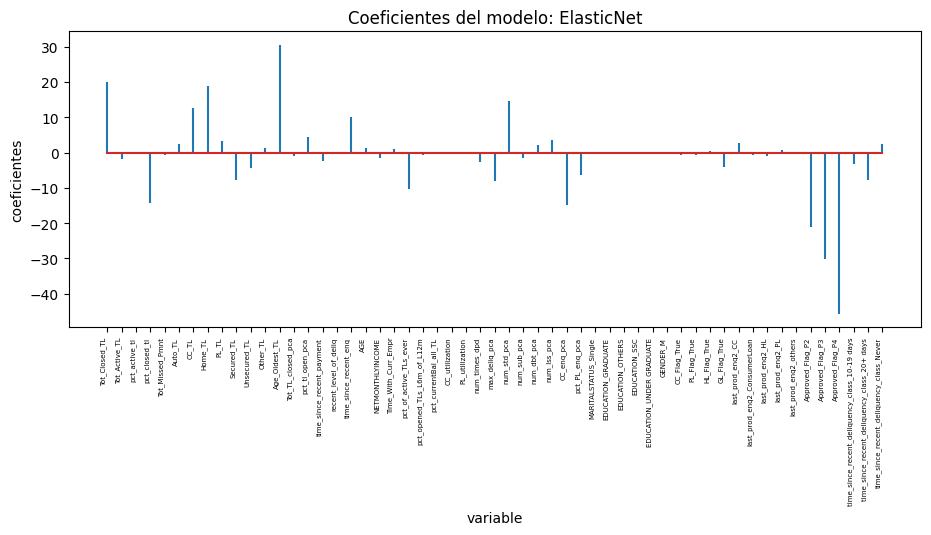

In [25]:
# Gráfico de los coeficientes del modelo  
graficar_coeficientes(modelo_elastic_final, X_train)

In [26]:
# Evalúa el modelo entrenado con los datos de prueba
evaluar_modelos(modelo_elastic_final, X_test, y_test)

,R^2,RMSE
LinearRegression,0.806172,9.228732
ElasticNet,0.806082,9.230871
Ridge,0.804631,9.265352
Lasso,0.798215,9.416252


## 3. Regresión Lineal 

Evaluación del modelo: LinearRegression


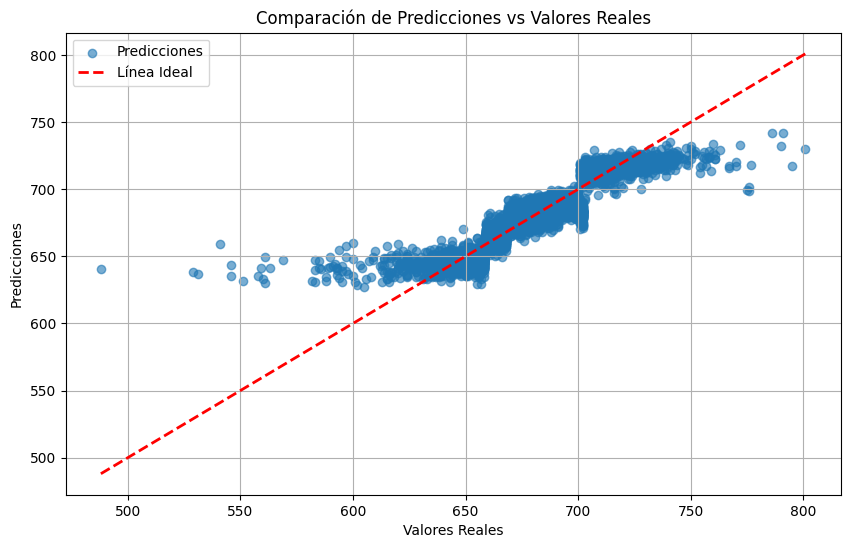

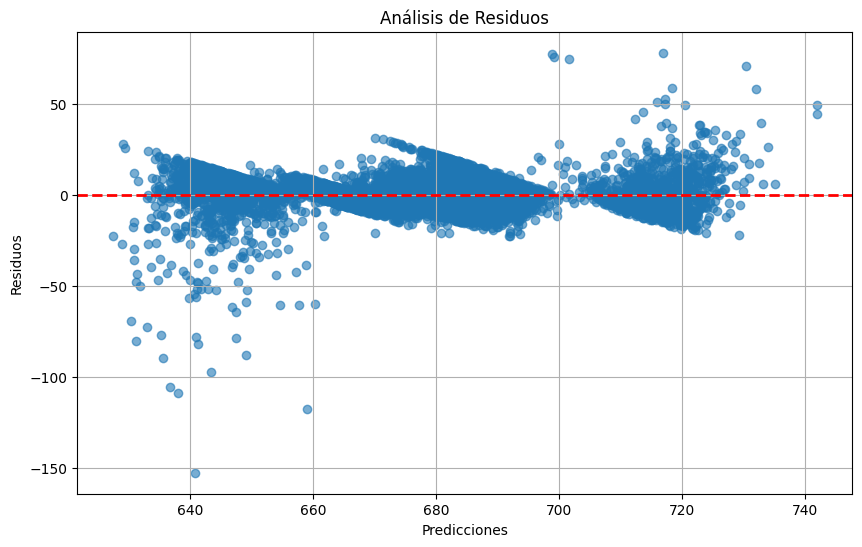

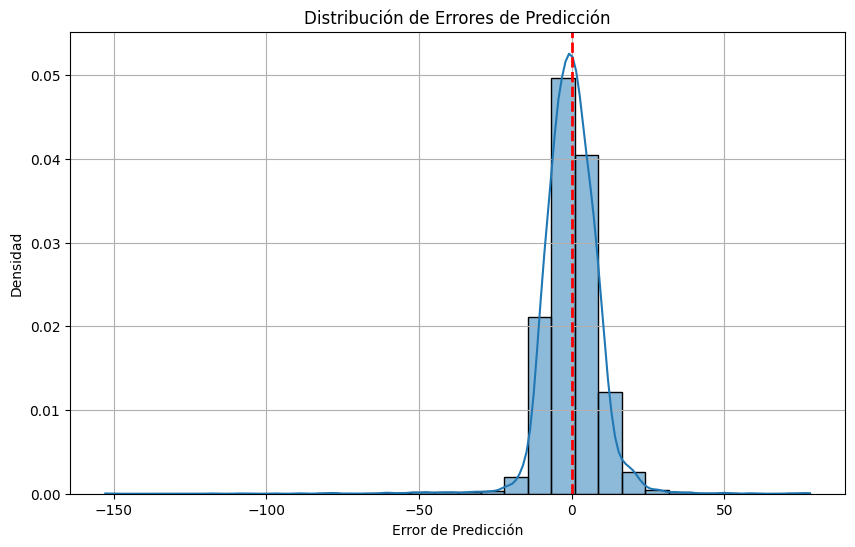

In [27]:
# Graficar entrenamiento del modelo
evaluar_entrenamiento(linear, X_test, y_test)

Debido a que la Regresión Lineal por si misma arroja unos mejores resultados que las regularizaciones procedemos a seleccionarla para estudiar sus valores SHAP

In [28]:
# Crear el explicador de SHAP para el mejor modelo de regresión lineal
explainer = shap.LinearExplainer(
    model=linear, 
    masker=shap.maskers.Independent(X_train),
    feature_perturbation='interventional')

# Obtener valores SHAP en formato Explanation
shap_values = explainer(X_test)

C:\Users\Ismael Laso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\shap\explainers\_linear.py:95: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


Ejecutando visualización 1: Bar Plot


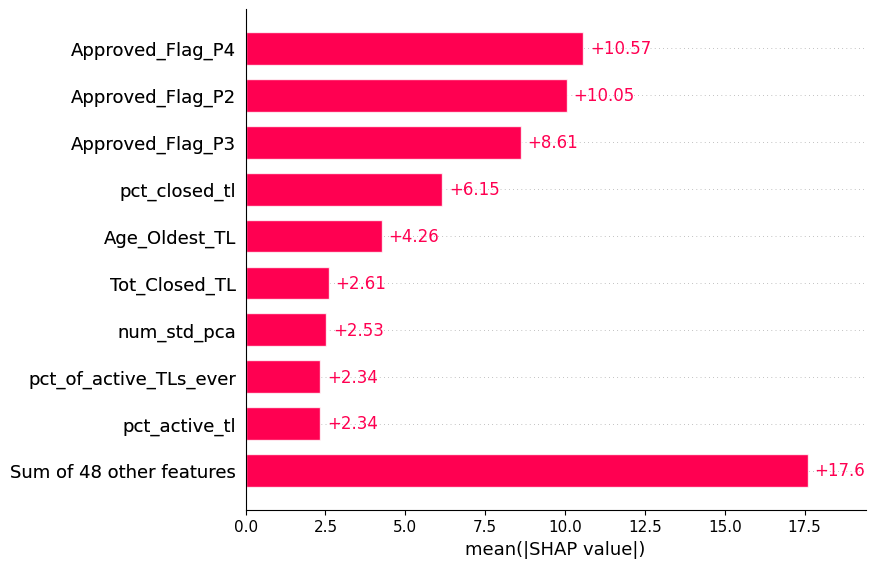

Ejecutando visualización 2: Waterfall Plot


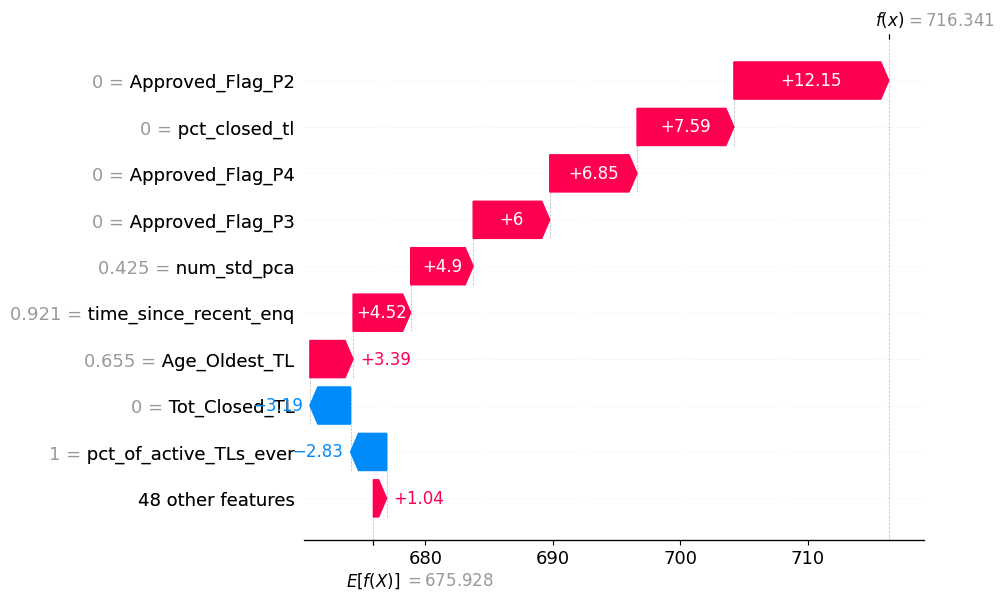

Ejecutando visualización 3: Beeswarm Plot


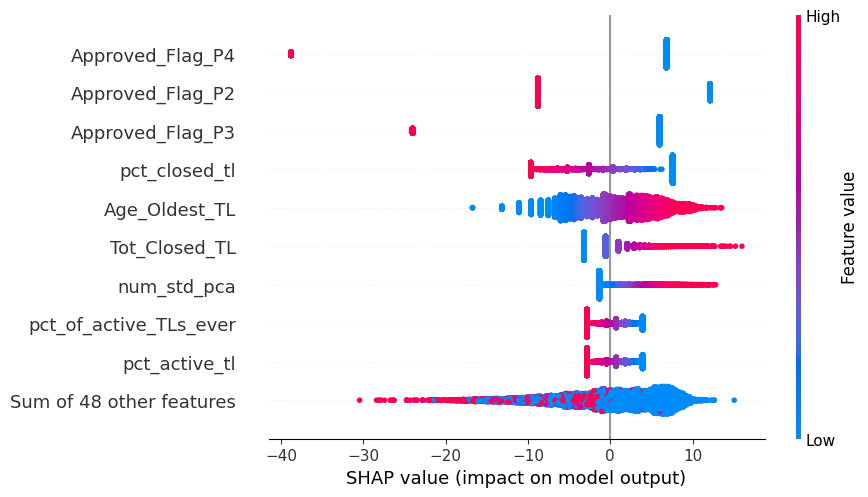

Ejecutando visualización 4: Scatter Plots


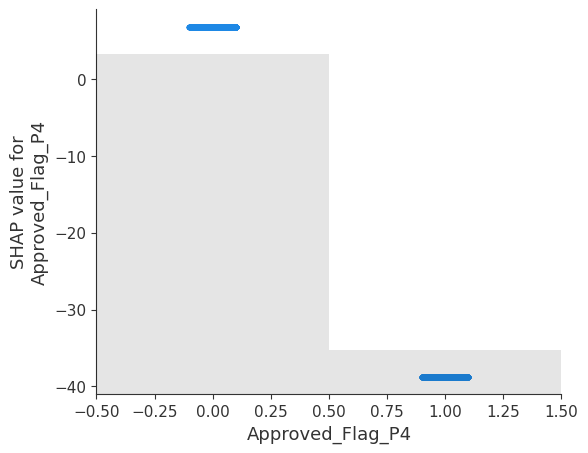

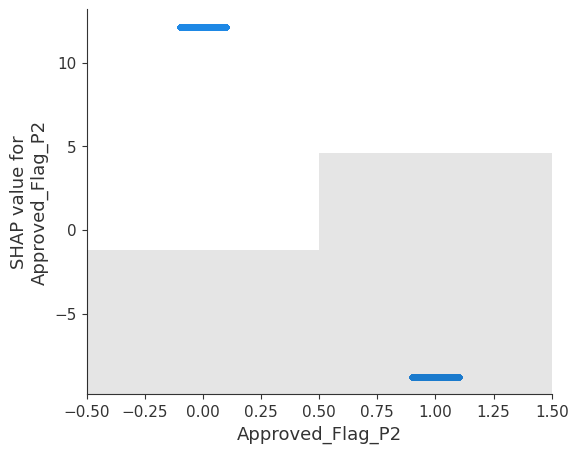

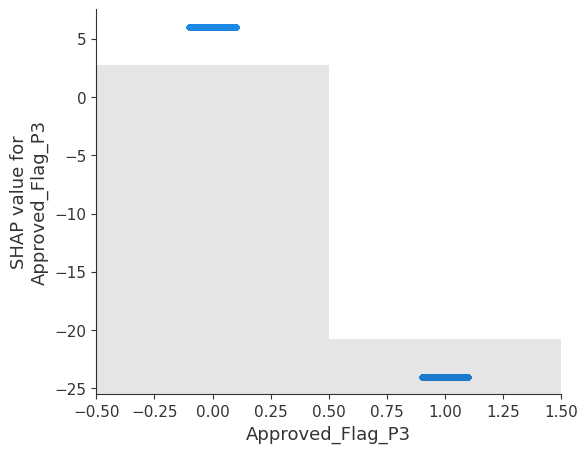

In [29]:
# Representamos todas las gráficas que hemos decidico representar de la librería SHAP
shap_visualization(shap_values, X_test)

**shap.force_plot** no admite múltiples muestras con matplotlib, para ello sería necesario recorer varias observaciones de forma secuencial. Debido a ello, esta visualización se representa fuera de la función.

In [30]:
# Force Plot: Explicación visual de hasta 50 observaciones  
shap.force_plot(shap_values[:50])

## 4. K-Nearest Neighbours (KNN)

In [31]:
# Definir el rango de valores de k a evaluar
param_grid = {'n_neighbors': range(1, 30)}

# Crear el modelo kNN para regresión
knn = KNeighborsRegressor()

# Configurar GridSearchCV con validación cruzada de 5 folds
grid_search = GridSearchCV(
    knn, 
    param_grid, 
    cv=5, 
    scoring=make_scorer(mean_squared_error, greater_is_better=False),
    n_jobs=-1
)

# Ajustar el modelo en los datos de entrenamiento
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'n_neighbors': range(1, 30)},
             scoring=make_scorer(mean_squared_error, greater_is_better=False, response_method='predict'))

In [32]:
# Obtener el mejor modelo entrenado tras la búsqueda de hiperparámetros
best_knn = grid_search.best_estimator_

# Imprimime mejores hiperparámetros
df_best_params(grid_search)


Mejores hiperparámetros encontrados:
  Hiperparámetro  Valor
0    n_neighbors     13


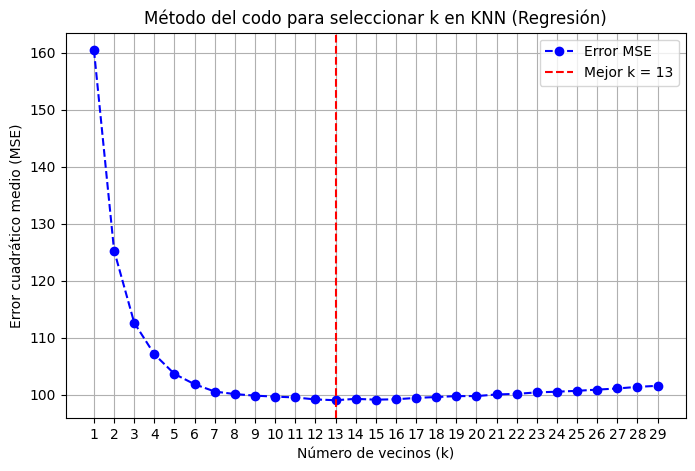

In [33]:
# Obtener la evolución del error en función de k
k_values = param_grid['n_neighbors']
errors = -grid_search.cv_results_['mean_test_score']
best_k = grid_search.best_params_['n_neighbors']

# Graficar la evolución del error
plt.figure(figsize=(8, 5))
plt.plot(k_values, errors, marker='o', linestyle='dashed', color='b', label="Error MSE")
plt.axvline(best_k, linestyle="--", color="r", label=f"Mejor k = {best_k}")
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Error cuadrático medio (MSE)")
plt.title("Método del codo para seleccionar k en KNN (Regresión)")
plt.xticks(k_values)
plt.legend()
plt.grid()

In [34]:
# Evalúa el modelo entrenado con los datos de prueba
evaluar_modelos(best_knn, X_test, y_test)

,R^2,RMSE
LinearRegression,0.806172,9.228732
ElasticNet,0.806082,9.230871
Ridge,0.804631,9.265352
Lasso,0.798215,9.416252
KNeighborsRegressor,0.746412,10.555969


Evaluación del modelo: KNeighborsRegressor


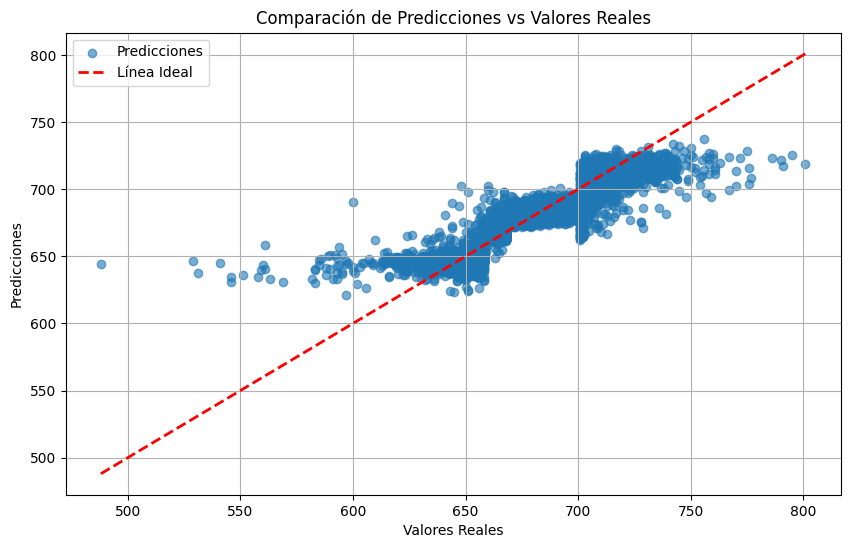

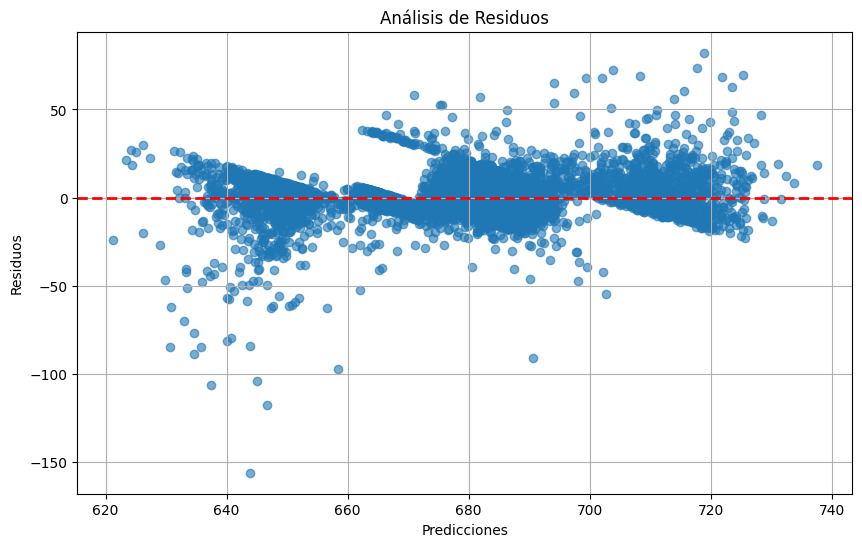

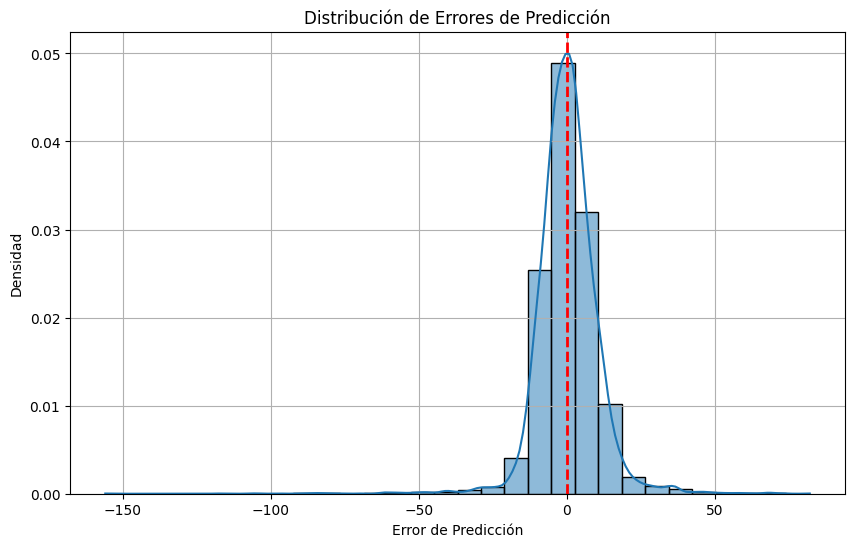

In [35]:
# Graficar entrenamiento del modelo
evaluar_entrenamiento(best_knn, X_test, y_test)

In [36]:
# Usar K-Means para agrupar y reducir los datos de referencia a 50 centroides
background_kmeans = shap.kmeans(X_train, 50)
background_kmeans_array = np.array(background_kmeans.data)

# Crear el explicador con el conjunto reducido
explainer = shap.KernelExplainer(
    model=best_knn.predict,
    data=background_kmeans_array,
    masker=shap.maskers.Independent(background_kmeans_array)
)

# Obtener valores SHAP para las primeras 10 muestras de prueba
shap_values = explainer(X_test.iloc[0:20, :])

  0%|          | 0/20 [00:00<?, ?it/s]

Ejecutando visualización 1: Bar Plot


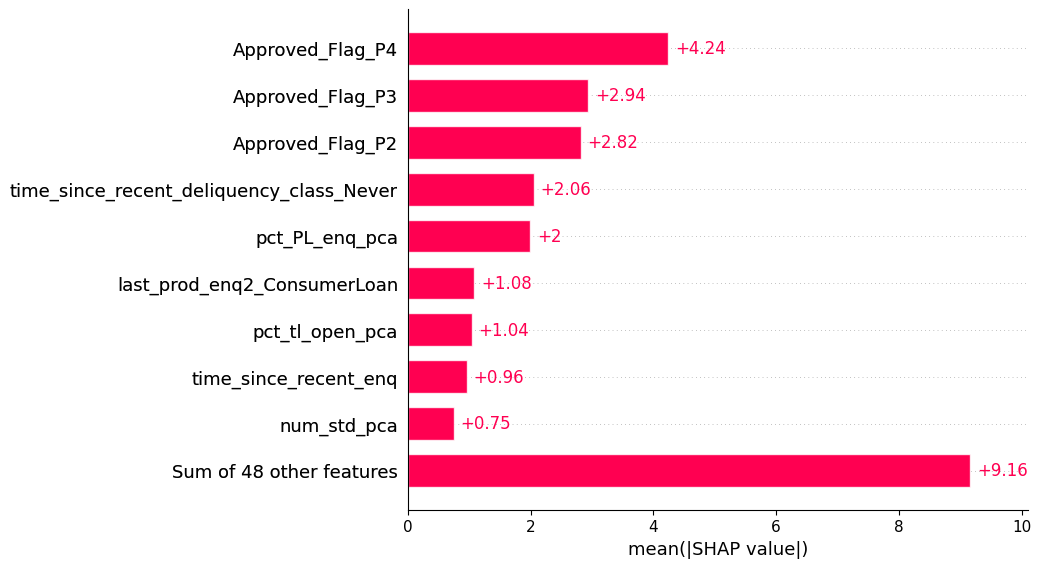

Ejecutando visualización 2: Waterfall Plot


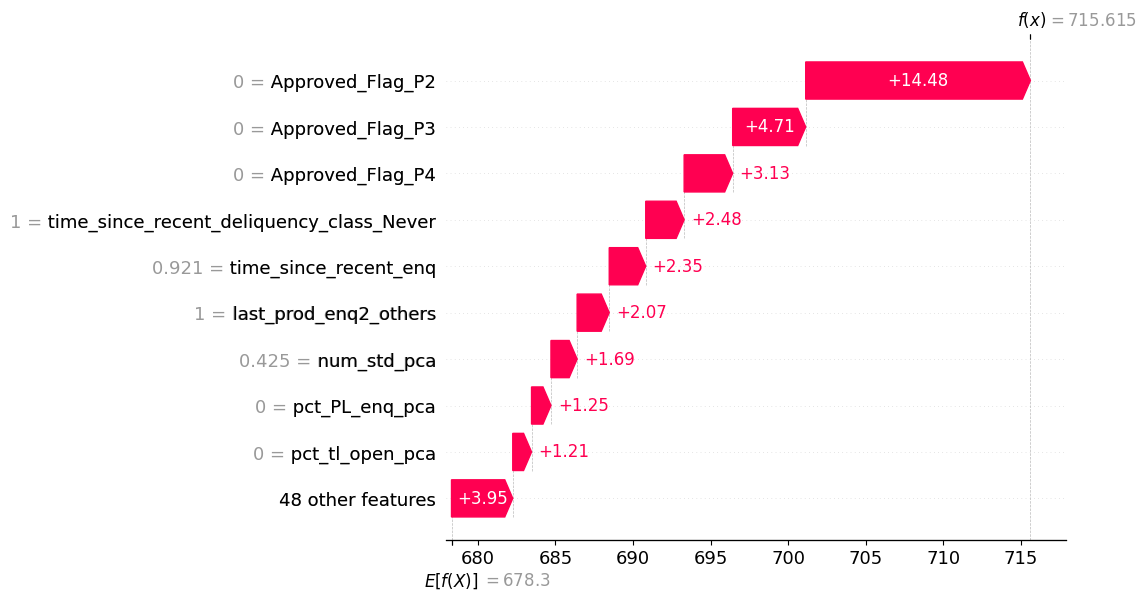

Ejecutando visualización 3: Beeswarm Plot


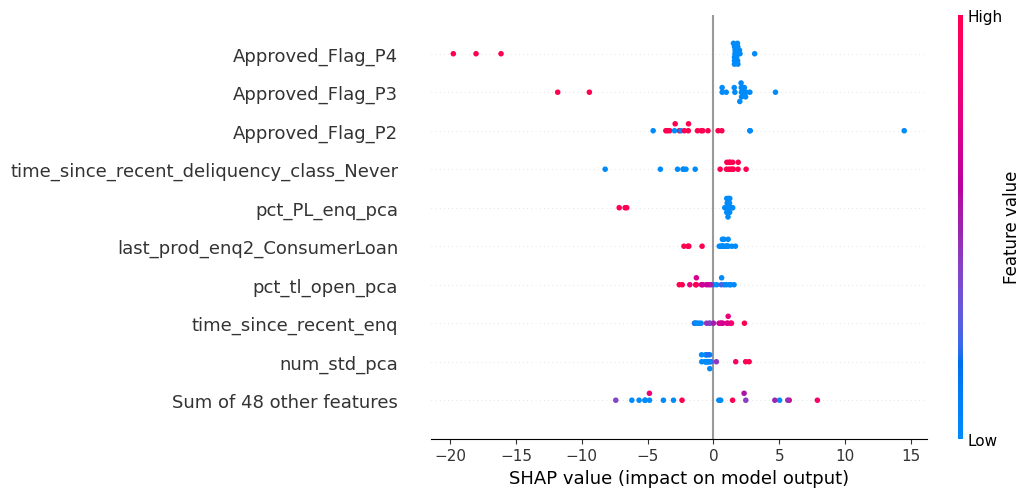

Ejecutando visualización 4: Scatter Plots


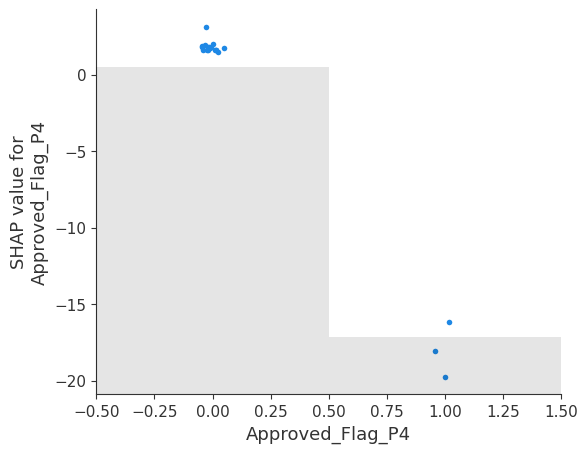

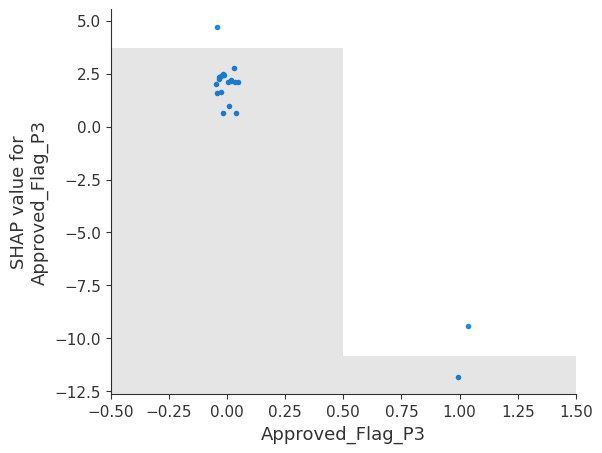

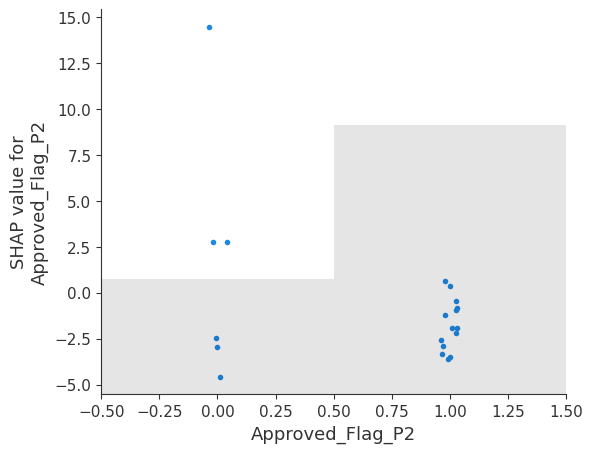

In [37]:
# Representamos todas las gráficas que hemos decidico representar de la librería SHAP
shap_visualization(shap_values, X_test)

In [38]:
# Force Plot: Explicación visual de hasta 50 observaciones  
shap.force_plot(shap_values[:50])

## 5. Modelos basados en árboles de decisión

### 5.1. Árbol de decisión

In [39]:
# Definir el rango de hiperparámetros
param_dist = {
    'criterion': ['squared_error', 'friedman_mse'],
    'max_depth': range(8, 17, 1),
    'min_samples_split': [10, 15, 20],
    'max_features': ['sqrt', 'log2']
}

# Crear el modelo de árbol de decisión para regresión
tree = DecisionTreeRegressor()

# Configurar GridSearchCV con validación cruzada de 3 folds
random_search = RandomizedSearchCV(
    tree, 
    param_distributions=param_dist,  
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',  
    n_jobs=-1,  
    random_state=29,  
    verbose=1  
)

# Ajustar el modelo en los datos de entrenamiento
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=DecisionTreeRegressor(), n_iter=50,
                   n_jobs=-1,
                   param_distributions={'criterion': ['squared_error',
                                                      'friedman_mse'],
                                        'max_depth': range(8, 17),
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_split': [10, 15, 20]},
                   random_state=29, scoring='neg_mean_squared_error',
                   verbose=1)

In [40]:
# Obtener el mejor modelo
best_tree = random_search.best_estimator_

# Imprimime mejores hiperparámetros
df_best_params(random_search)


Mejores hiperparámetros encontrados:
      Hiperparámetro          Valor
0  min_samples_split             15
1       max_features           sqrt
2          max_depth             12
3          criterion  squared_error


In [41]:
# Evalúa el modelo entrenado con los datos de prueba
evaluar_modelos(best_tree, X_test, y_test)

,R^2,RMSE
LinearRegression,0.806172,9.228732
ElasticNet,0.806082,9.230871
Ridge,0.804631,9.265352
Lasso,0.798215,9.416252
KNeighborsRegressor,0.746412,10.555969
DecisionTreeRegressor,0.710341,11.281771


### 5.2. Random Forest

In [42]:
# Definir el modelo
forest = RandomForestRegressor()

# Definir la parrilla de hiperparámetros
param_dist = {
    'n_estimators': randint(100, 1000),
    'criterion': ['squared_error', 'friedman_mse'],
    'max_depth': randint(3, 10),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'max_features': ['sqrt', 'log2']
}

# Configurar la búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=forest,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=29,
    n_jobs=-1
)

# Ejecutar la búsqueda
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=50,
                   n_jobs=-1,
                   param_distributions={'criterion': ['squared_error',
                                                      'friedman_mse'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001E95711CDD0>,
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001E95740F490>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001E957159490>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001E95711C7D0>},
                   random_state=29, scoring='neg_mean_squared_error',
                   verbose=2)

In [43]:
# Obtener el mejor modelo
best_forest = random_search.best_estimator_

# Imprimime mejores hiperparámetros
df_best_params(random_search)


Mejores hiperparámetros encontrados:
      Hiperparámetro          Valor
0          criterion  squared_error
1          max_depth              9
2       max_features           sqrt
3   min_samples_leaf             15
4  min_samples_split              5
5       n_estimators            366


In [44]:
# Evalúa el modelo entrenado con los datos de prueba
evaluar_modelos(best_forest, X_test, y_test)

,R^2,RMSE
LinearRegression,0.806172,9.228732
ElasticNet,0.806082,9.230871
Ridge,0.804631,9.265352
RandomForestRegressor,0.801448,9.340512
Lasso,0.798215,9.416252
KNeighborsRegressor,0.746412,10.555969
DecisionTreeRegressor,0.710341,11.281771


### 5.3. XGBoost

In [45]:
# Definir el modelo
xgb = xgb.XGBRegressor(tree_method='hist', objective='reg:squarederror')

# Definir la parrilla de hiperparámetros
param_dist = {
    'n_estimators': randint(200, 1200),
    'learning_rate': uniform(0.005, 0.3),
    'max_depth': randint(4, 15),
    'min_child_weight': randint(1, 15),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 15),
    'reg_alpha': uniform(0, 2),
    'reg_lambda': uniform(0, 2)
}

# Configurar la búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=29,
    n_jobs=-1
)

# Ejecutar la búsqueda
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001E9570D8E10>,
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E957499E90>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E95749BF50>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E9574A0090>},
                   random_state=29, scoring='neg_mean_squared_error',
                   verbose=2)

In [46]:
# Obtener el mejor modelo
best_xgb = random_search.best_estimator_

# Imprimime mejores hiperparámetros
df_best_params(random_search)


Mejores hiperparámetros encontrados:
     Hiperparámetro       Valor
0  colsample_bytree    0.872759
1             gamma    8.778080
2     learning_rate    0.033239
3         max_depth    6.000000
4  min_child_weight    7.000000
5      n_estimators  743.000000
6         reg_alpha    1.482022
7        reg_lambda    1.177261
8         subsample    0.796580


In [47]:
# Evalúa el modelo entrenado con los datos de prueba
evaluar_modelos(best_xgb, X_test, y_test)

,R^2,RMSE
XGBRegressor,0.876674,7.361418
LinearRegression,0.806172,9.228732
ElasticNet,0.806082,9.230871
Ridge,0.804631,9.265352
RandomForestRegressor,0.801448,9.340512
Lasso,0.798215,9.416252
KNeighborsRegressor,0.746412,10.555969
DecisionTreeRegressor,0.710341,11.281771


### 5.4. Mejor modelo de Árbol (XGB)

Evaluación del modelo: XGBRegressor


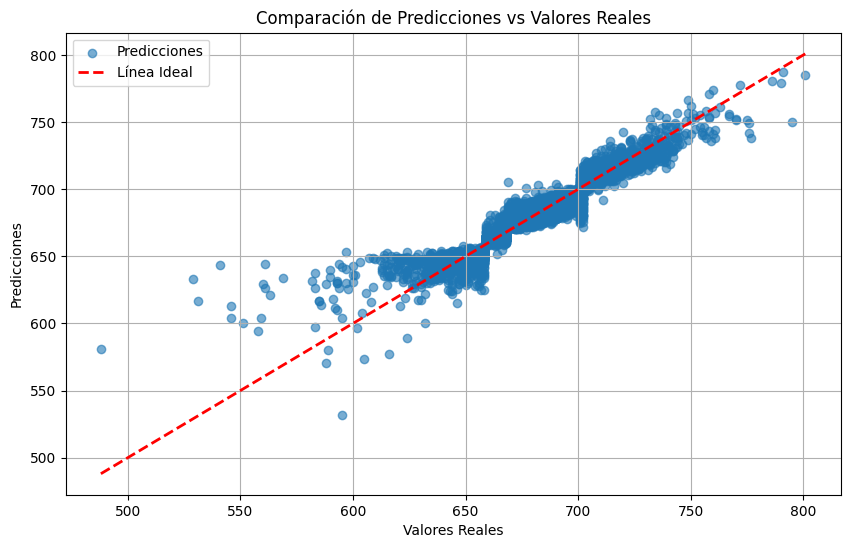

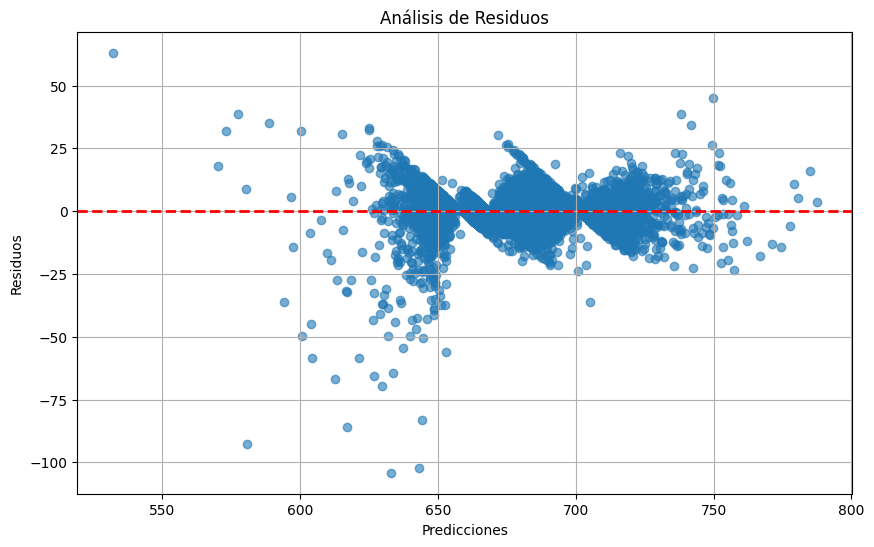

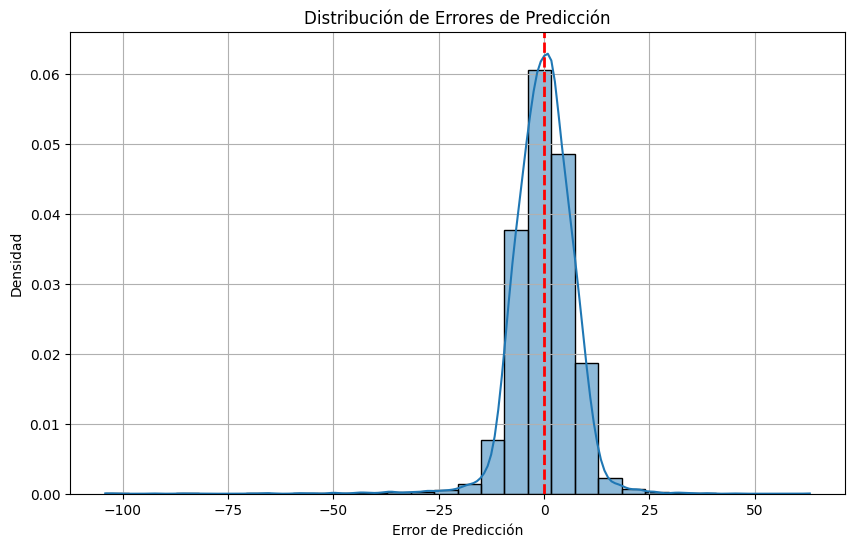

In [48]:
# Graficar entrenamiento del modelo
evaluar_entrenamiento(best_xgb, X_test, y_test)

Como el modelo basado en árboles que mejor predicción ha arrojado es el entrenado con XGBoost, escogemos a este para analizar sus valores SHAP.

In [49]:
# Crear el explicador de SHAP para el mejor modelo de árbol de decisión
explainer = shap.TreeExplainer(
    model=best_xgb,
    data=X_train,
    model_output='raw',
    feature_perturbation='interventional')

# Obtener los valores SHAP para todo el conjunto de prueba
shap_values = explainer(X_test)

100%|===================| 10249/10268 [05:38<00:00]        

Ejecutando visualización 1: Bar Plot


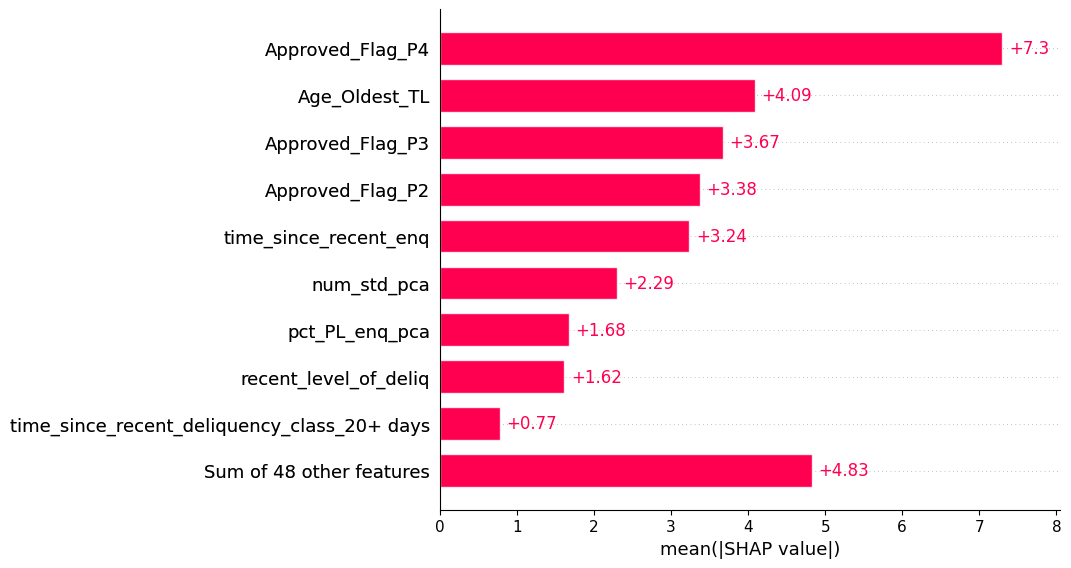

Ejecutando visualización 2: Waterfall Plot


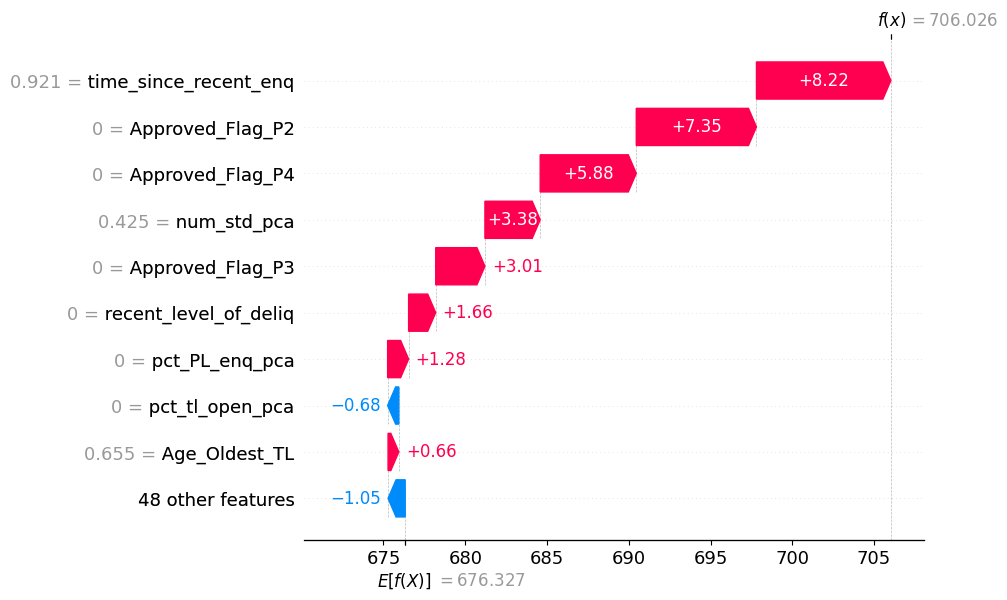

Ejecutando visualización 3: Beeswarm Plot


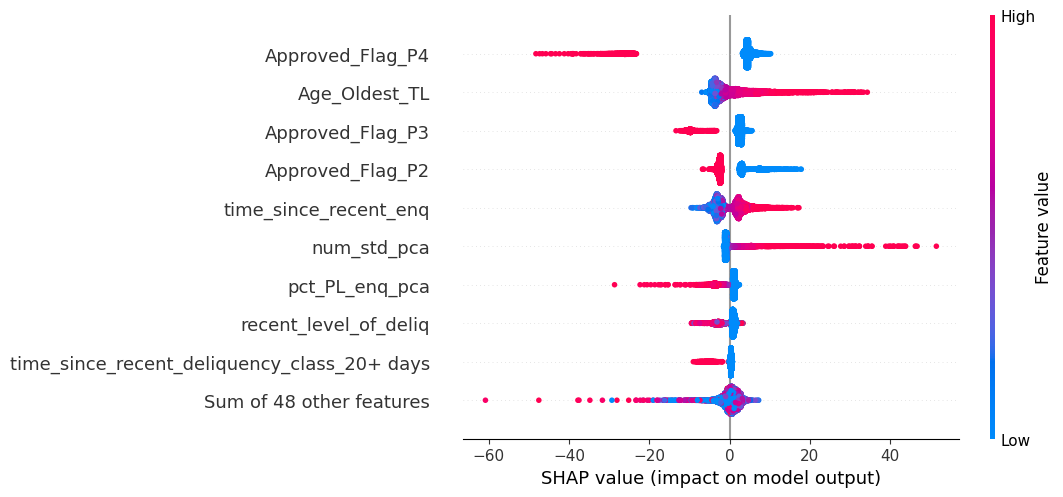

Ejecutando visualización 4: Scatter Plots


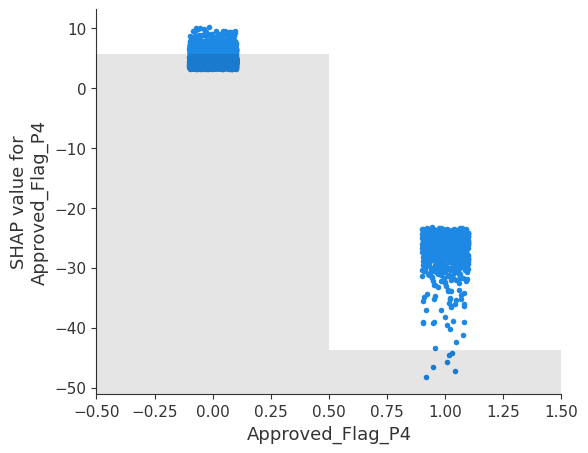

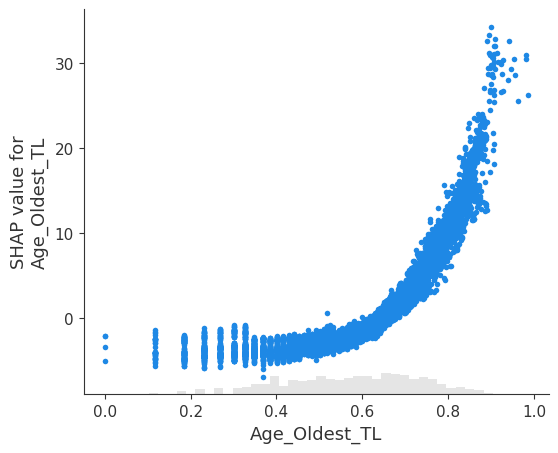

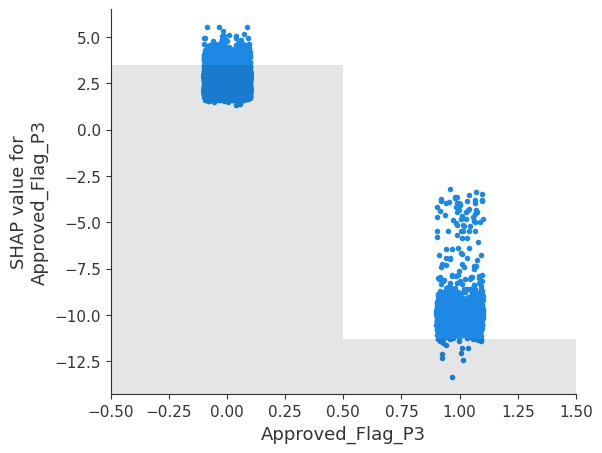

In [50]:
# Representamos todas las gráficas que hemos decidico representar de la librería SHAP
shap_visualization(shap_values, X_test)

In [51]:
# Force Plot: Explicación visual de hasta 50 observaciones  
shap.force_plot(shap_values[:50])

## 6. SVM

In [52]:
# Definir el modelo
svr = LinearSVR()

# Definir la parrilla de hiperparámetros
param_dist = {
    'C': uniform(0.1, 10),
    'epsilon': uniform(0.01, 1),
    'max_iter': randint(100, 1000)
}

# Configurar la búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=svr,
    param_distributions=param_dist,
    n_iter=200,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=29,
    n_jobs=-1
)

# Ejecutar la búsqueda
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


RandomizedSearchCV(cv=5, estimator=LinearSVR(), n_iter=200, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E9570EC210>,
                                        'epsilon': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E95730C0D0>,
                                        'max_iter': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001E9517FC7D0>},
                   random_state=29, scoring='neg_mean_squared_error',
                   verbose=2)

In [53]:
# Obtener el mejor modelo
best_svr = random_search.best_estimator_

# Imprimime mejores hiperparámetros
df_best_params(random_search)


Mejores hiperparámetros encontrados:
  Hiperparámetro       Valor
0              C   10.031367
1        epsilon    0.605364
2       max_iter  972.000000


In [54]:
# Evalúa el modelo entrenado con los datos de prueba
evaluar_modelos(best_svr, X_test, y_test)

,R^2,RMSE
XGBRegressor,0.876674,7.361418
LinearRegression,0.806172,9.228732
ElasticNet,0.806082,9.230871
Ridge,0.804631,9.265352
RandomForestRegressor,0.801448,9.340512
Lasso,0.798215,9.416252
LinearSVR,0.790012,9.605730
KNeighborsRegressor,0.746412,10.555969
DecisionTreeRegressor,0.710341,11.281771


Evaluación del modelo: LinearSVR


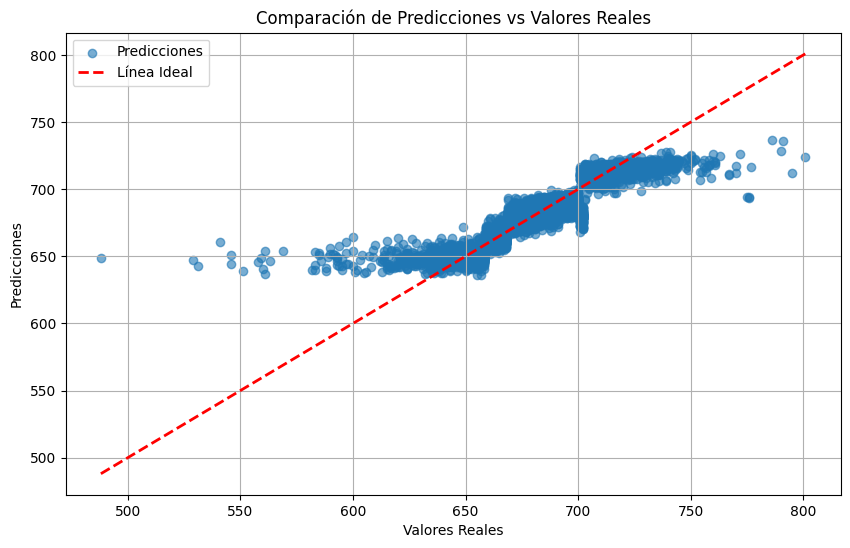

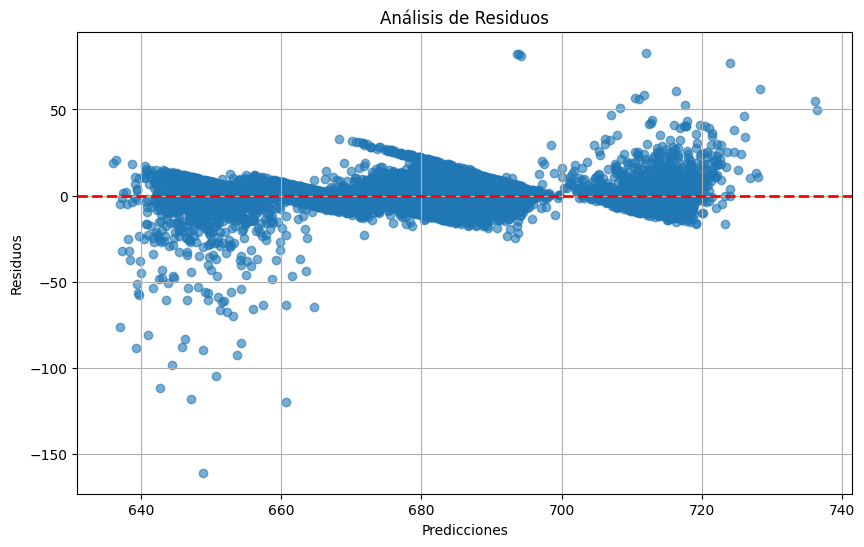

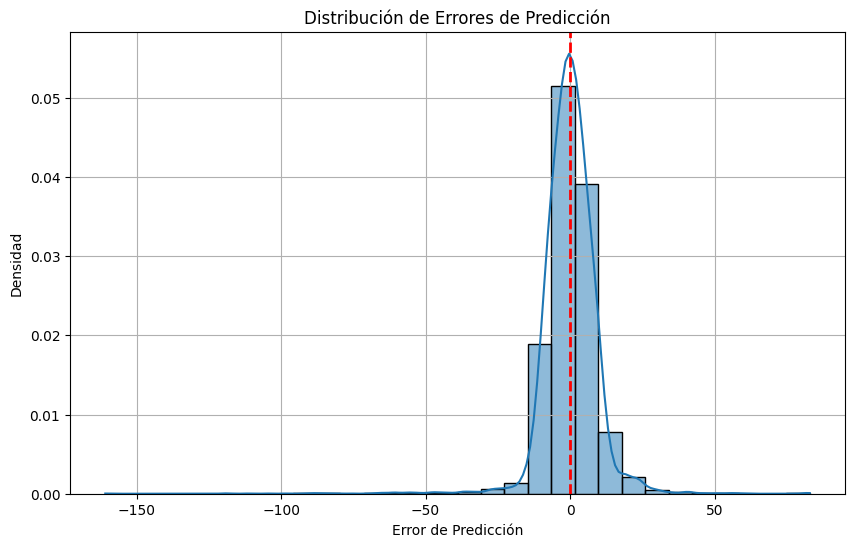

In [55]:
# Graficar entrenamiento del modelo
evaluar_entrenamiento(best_svr, X_test, y_test)

In [56]:
# Crear el explicador SHAP para SVR
explainer = shap.KernelExplainer(
    model=best_svr.predict,  
    data=X_train[:100],
    link="identity" 
)

# Calcular valores SHAP para un subconjunto de datos de prueba
shap_values = explainer(X_test[:20]) 

  0%|          | 0/20 [00:00<?, ?it/s]

Ejecutando visualización 1: Bar Plot


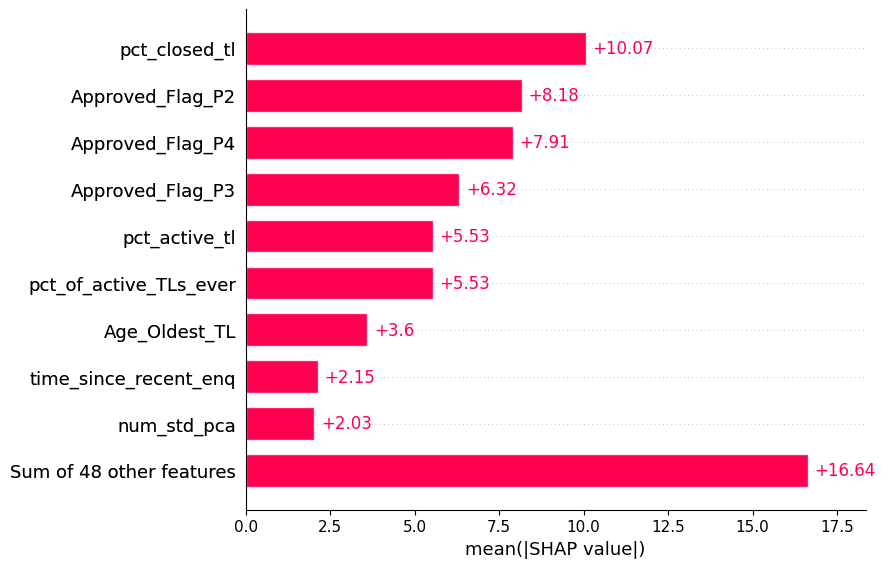

Ejecutando visualización 2: Waterfall Plot


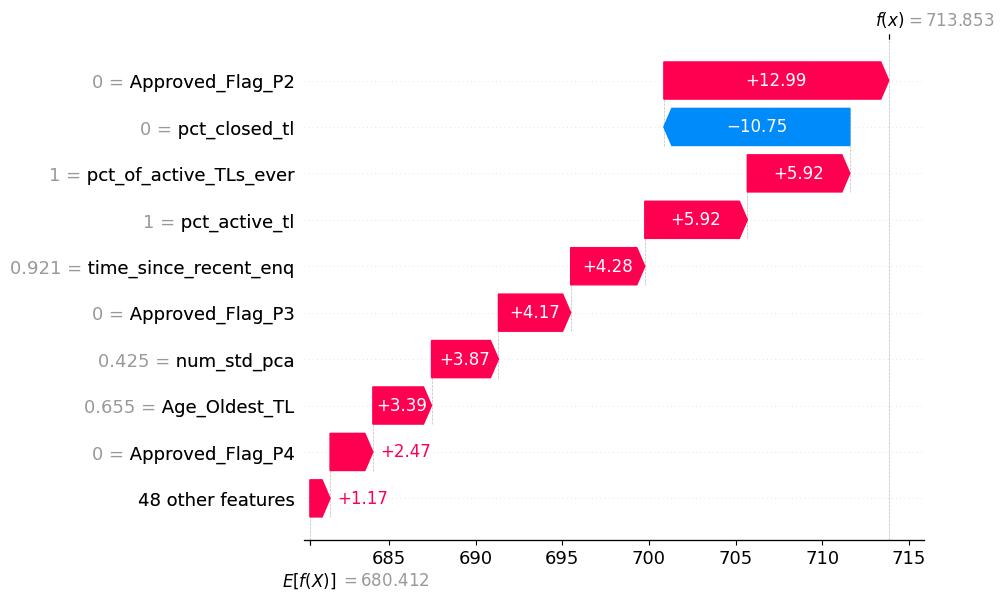

Ejecutando visualización 3: Beeswarm Plot


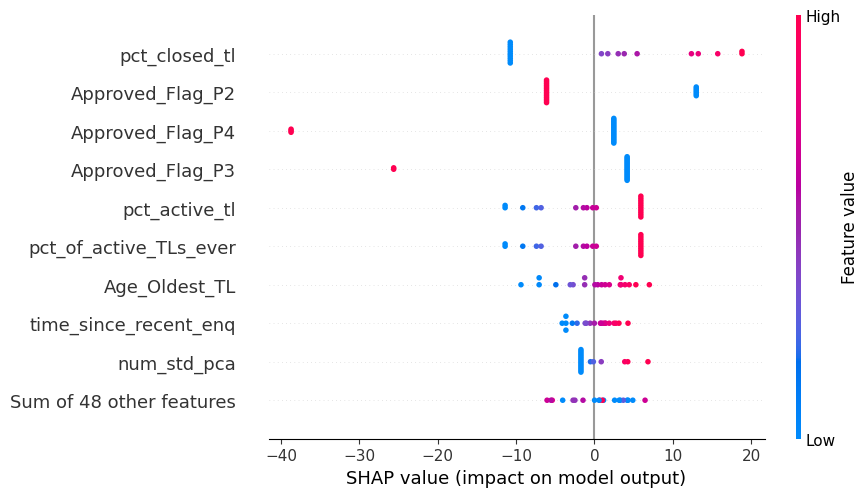

Ejecutando visualización 4: Scatter Plots


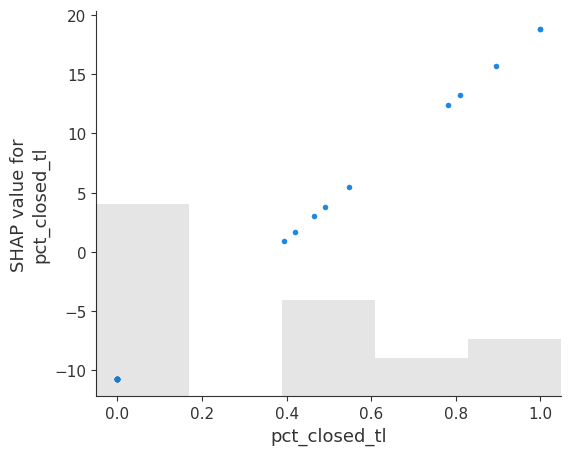

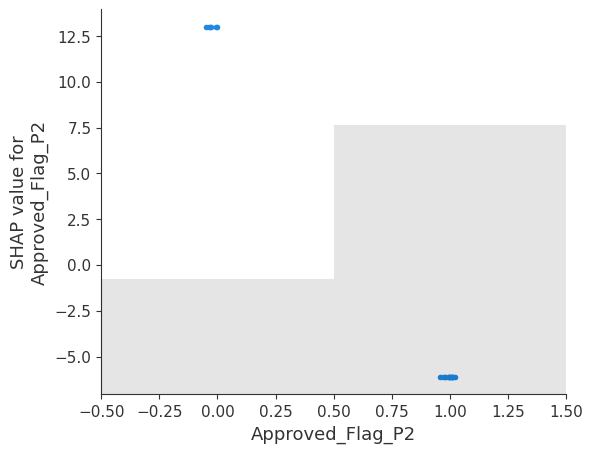

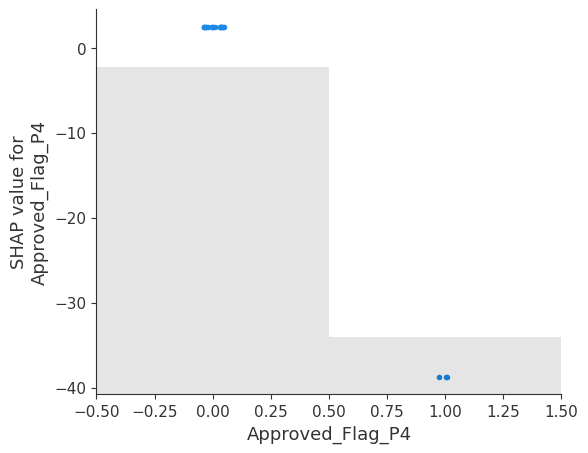

In [57]:
# Representamos todas las gráficas que hemos decidico representar de la librería SHAP
shap_visualization(shap_values, X_test)

In [58]:
# Force Plot: Explicación visual de hasta 50 observaciones  
shap.force_plot(shap_values[:50])

## 7. Red Neuronal Multicapa

In [59]:
# Transformamos la variable objetivo a una escala 0-1
scaler = MinMaxScaler()
Y_scaled = scaler.fit_transform(df[['Credit_Score']])

# Generamos el dataset de entrenamiento y el de test
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    X, Y_scaled, test_size=0.20, random_state=29, shuffle=True)

In [60]:
# Función para el ajuste de la tasa de aprendizaje
def lr_scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * 0.95

# Crear el modelo
dense = Sequential()

# Capa de entrada con normalización y activación LeakyReLU
dense.add(Input(shape=(X_train_scaled.shape[1],)))
dense.add(Dense(256, kernel_regularizer=l2(0.0005)))
dense.add(BatchNormalization()) 
dense.add(LeakyReLU(negative_slope=0.01))

# Capas ocultas con activación LeakyReLU y BatchNormalization
dense.add(Dense(128, kernel_regularizer=l2(0.0005)))
dense.add(BatchNormalization())
dense.add(LeakyReLU(negative_slope=0.01))

dense.add(Dense(64, kernel_regularizer=l2(0.0005)))
dense.add(BatchNormalization())
dense.add(LeakyReLU(negative_slope=0.01))

# Nueva capa oculta con 64 neuronas
dense.add(Dense(32, kernel_regularizer=l2(0.0005)))
dense.add(BatchNormalization())
dense.add(LeakyReLU(negative_slope=0.01))

# Dropout para evitar sobreajuste
dense.add(Dropout(0.2))

# Capa de salida (regresión)
dense.add(Dense(1, activation="linear"))

# Compilar el modelo con el optimizador Adam
optimizer = Adam(learning_rate=0.0005)

dense.compile(optimizer=optimizer, loss=Huber(), metrics=["mean_squared_error"])


# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_callback = LearningRateScheduler(lr_scheduler)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

# Entrenamiento del modelo
history = dense.fit(X_train_scaled, y_train_scaled, validation_data=(X_test_scaled, y_test_scaled), epochs=100, 
                    batch_size=256, callbacks=[early_stopping, lr_callback, reduce_lr])

Epoch 1/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.4045 - mean_squared_error: 0.4603 - val_loss: 0.2392 - val_mean_squared_error: 0.1082 - learning_rate: 5.0000e-04
Epoch 2/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.2388 - mean_squared_error: 0.1155 - val_loss: 0.1797 - val_mean_squared_error: 0.0218 - learning_rate: 5.0000e-04
Epoch 3/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1942 - mean_squared_error: 0.0599 - val_loss: 0.1530 - val_mean_squared_error: 0.0056 - learning_rate: 5.0000e-04
Epoch 4/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1632 - mean_squared_error: 0.0356 - val_loss: 0.1326 - val_mean_squared_error: 0.0032 - learning_rate: 5.0000e-04
Epoch 5/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1381 - mean_squared_error: 0.0237 - val_loss: 0.1134 - val_mean_squared_error: 0.0024 - learning_rate: 5.0000e-04
Epoch 6/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1161 - mean_squared_error: 0.0170 - val_loss: 0.

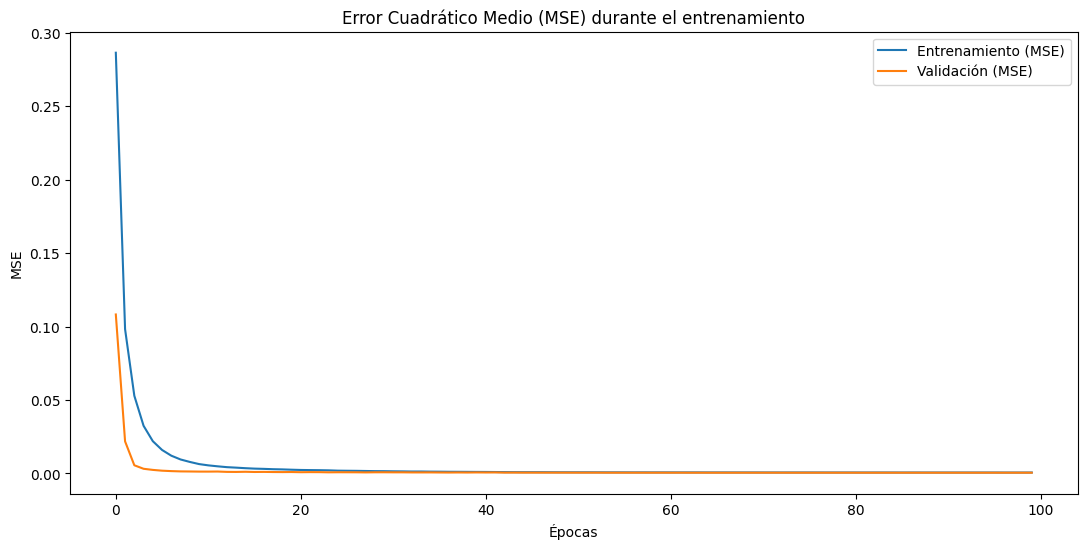

In [61]:
# Graficar los valores de error absoluto medio durante el entrenamiento
plt.figure(figsize=(13,6))
plt.plot(history.history['mean_squared_error'], label='Entrenamiento (MSE)')
plt.plot(history.history['val_mean_squared_error'], label='Validación (MSE)')
plt.title('Error Cuadrático Medio (MSE) durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [62]:
# Evalúa el modelo entrenado con los datos de prueba
evaluar_modelos(dense, X_test_scaled, y_test_scaled)

321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,R^2,RMSE
XGBRegressor,0.876674,7.361418
Sequential,0.867749,0.022290
LinearRegression,0.806172,9.228732
ElasticNet,0.806082,9.230871
Ridge,0.804631,9.265352
RandomForestRegressor,0.801448,9.340512
Lasso,0.798215,9.416252
LinearSVR,0.790012,9.605730
KNeighborsRegressor,0.746412,10.555969
DecisionTreeRegressor,0.710341,11.281771


1284/1284 ━━━━━━━━━━━━━━━━━━━━ 1s 878us/step
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


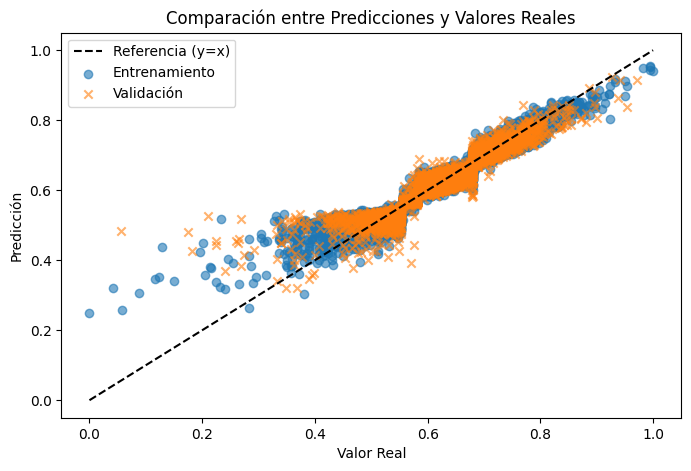

In [63]:
y_pred_train = dense.predict(X_train_scaled)
y_pred_test = dense.predict(X_test_scaled)

plt.figure(figsize=(8,5))
x_vals = np.linspace(0, 1, 100)
plt.plot(x_vals, x_vals, color="black", linestyle="dashed", label="Referencia (y=x)")
plt.scatter(y_train_scaled, y_pred_train, label="Entrenamiento", alpha=0.6)
plt.scatter(y_test_scaled, y_pred_test, label="Validación", alpha=0.6, marker="x")
plt.xlabel("Valor Real")
plt.ylabel("Predicción")
plt.legend()
plt.title("Comparación entre Predicciones y Valores Reales")
plt.show()

In [64]:
# Crear el explicador SHAP para SVR
explainer = shap.KernelExplainer(
    model=dense,  
    data=X_train[:100],
    link="identity" 
)

# Calcular valores SHAP para un subconjunto de datos de prueba
shap_values = explainer(X_test[:20]) 

# Elimina la dimensión extra
shap_values_reshaped = shap_values[:, :, 0] 


  0%|          | 0/20 [00:00<?, ?it/s]

Ejecutando visualización 1: Bar Plot


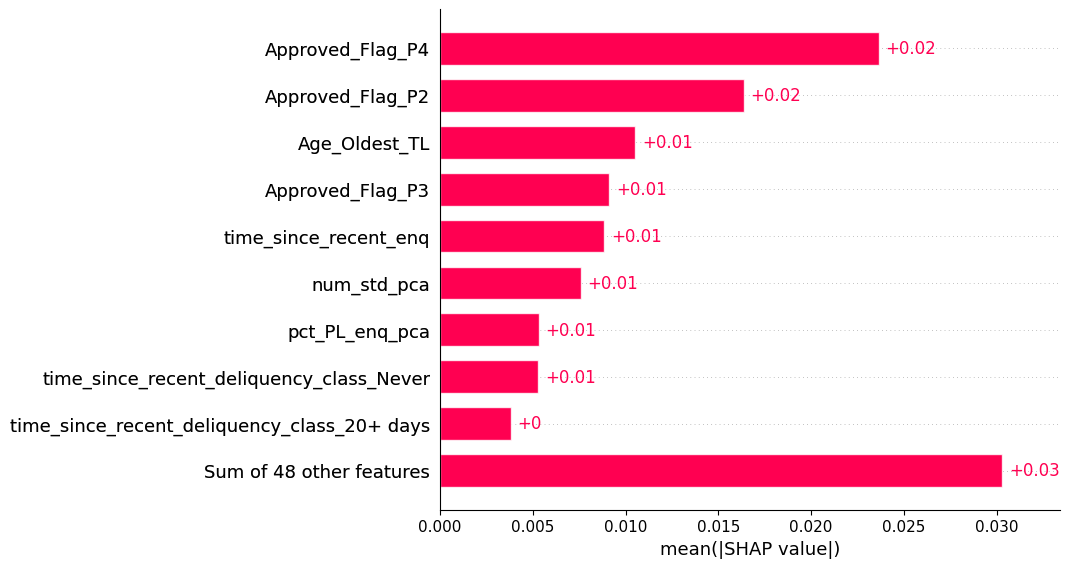

Ejecutando visualización 2: Waterfall Plot


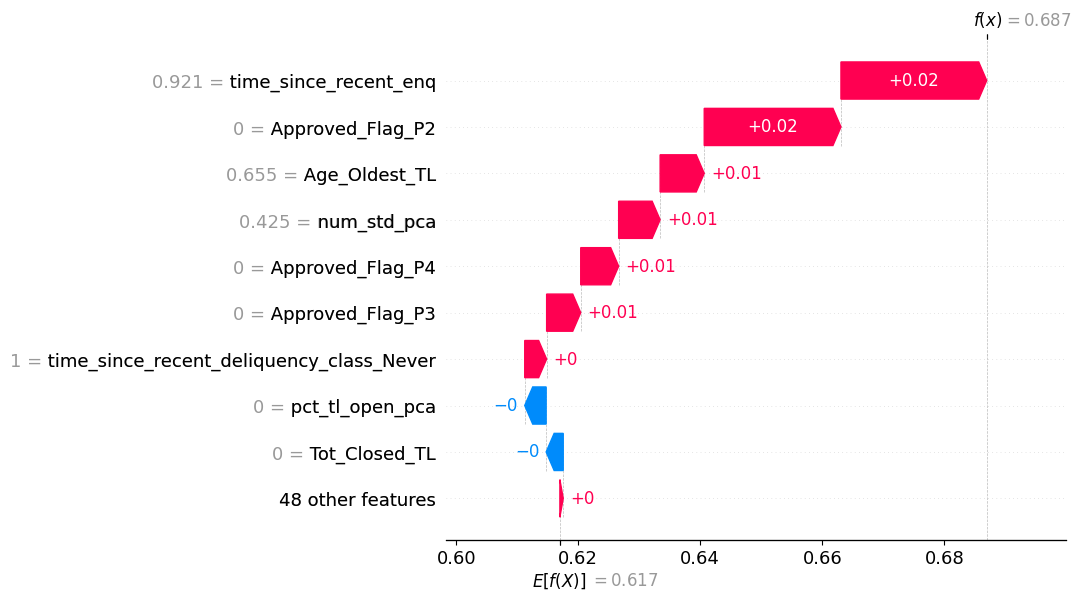

Ejecutando visualización 3: Beeswarm Plot


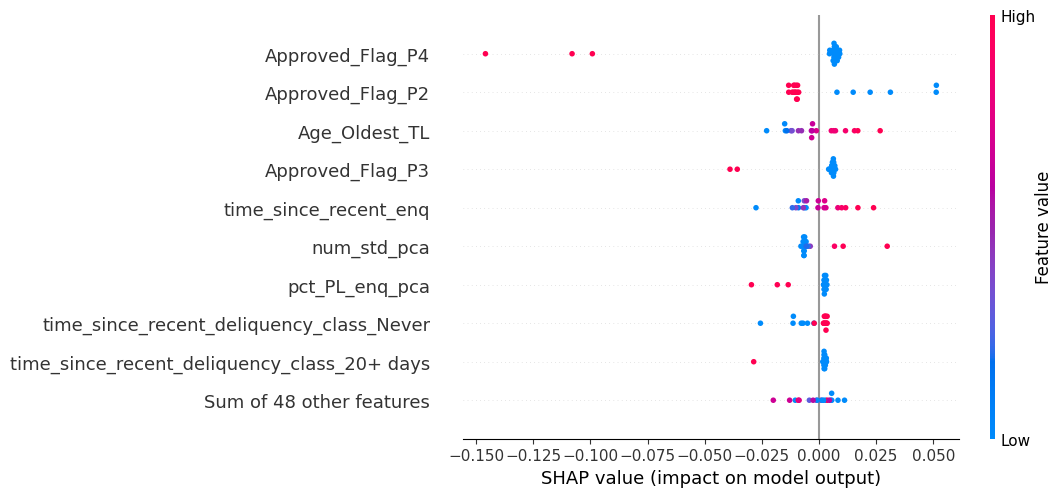

Ejecutando visualización 4: Scatter Plots


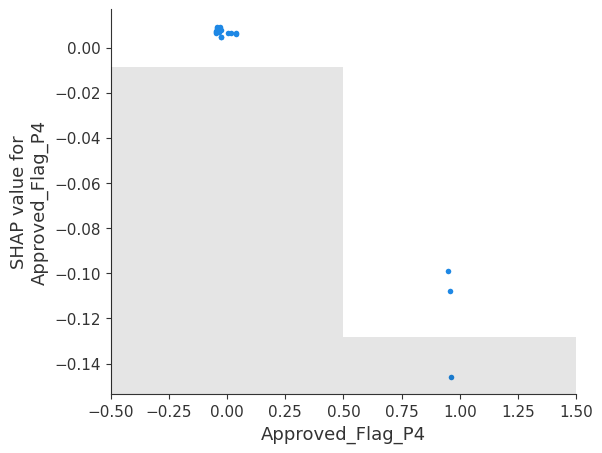

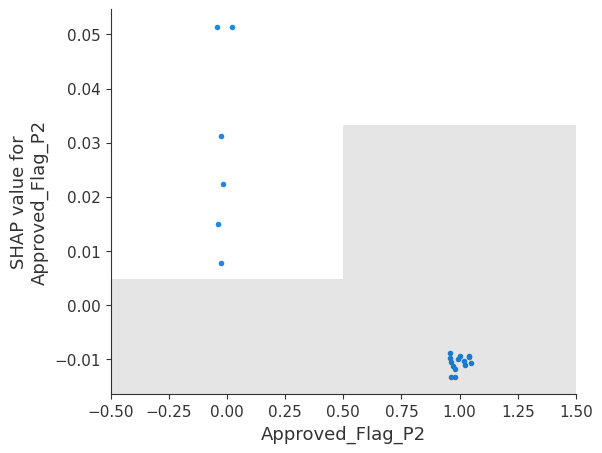

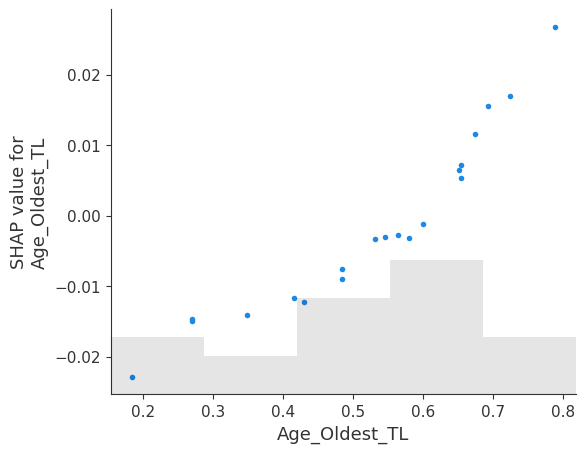

In [65]:
# Representamos todas las gráficas que hemos decidico representar de la librería SHAP
shap_visualization(shap_values_reshaped, X_test)

In [66]:
# Force Plot: Explicación visual de hasta 50 observaciones  
shap.force_plot(shap_values_reshaped[:50])